In [1]:
# suppress warnings
import warnings
warnings.simplefilter('ignore')
# import installed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [2]:
# add full path to import custom modules
full_path = '../scripts/'
## import
import sys
sys.path.insert(0, full_path)
from rate_functions import *
from simulation_tools_clean import *

## Generate data

Simulated datasets consist of 6 scenarios that manipulate the trend:
- No trend
- Increasing trend
- Breakpoint

and diel cycle:
- fixed amplitude
- increasing amplitude

The following cells generate data for each scenario across 1 week (7 days) to test 4 different diel models. 

### Scenario 1: No trend, fixed amplitude

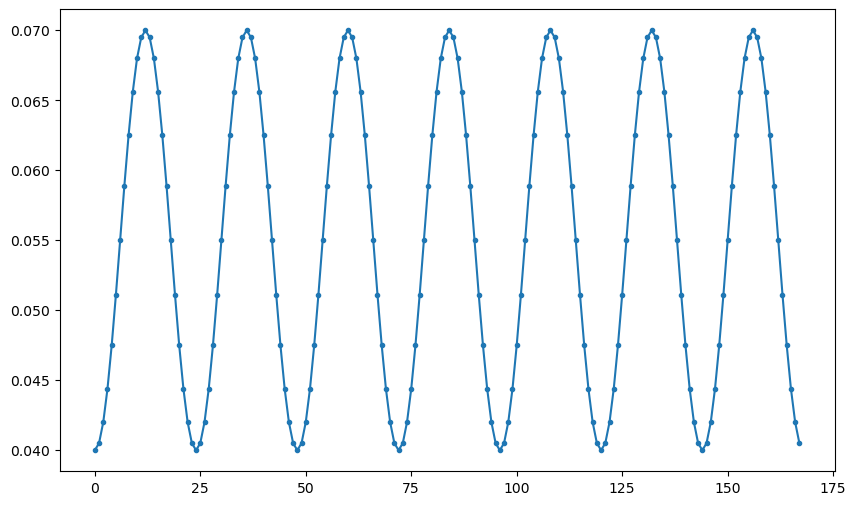

In [3]:
# generate simulation data with known periodicity of 24H, 10 full days
cycles = 8 # how many sine cycles
resolution = cycles*24 # how many datapoints to generate
# calculate length
length = np.pi * 2 * cycles
# set x with custom amplitude
x=np.arange(0, length, length / resolution)
# adjust amplitude and start/end
my_wave = 0.15*np.sin(x) + 0.55
start=np.where(my_wave == np.min(my_wave))[0][0]
end=np.where(my_wave == np.min(my_wave))[0][-1]-1
# crop wave
new_wave=my_wave[start:end+1]/10

# show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(new_wave, marker='.')

### Scenario 2: Increasing Trend, constant diel
A linear coefficient of 0.043 was added to the existing time series to add a trend while maintaining a representative range of _Prochlorococcus_ Qc. 

This scenario simulates a gradually increasing cell population that may represent SeaFlow passing through transition zones and/or encountering an increase of a different sub-population.

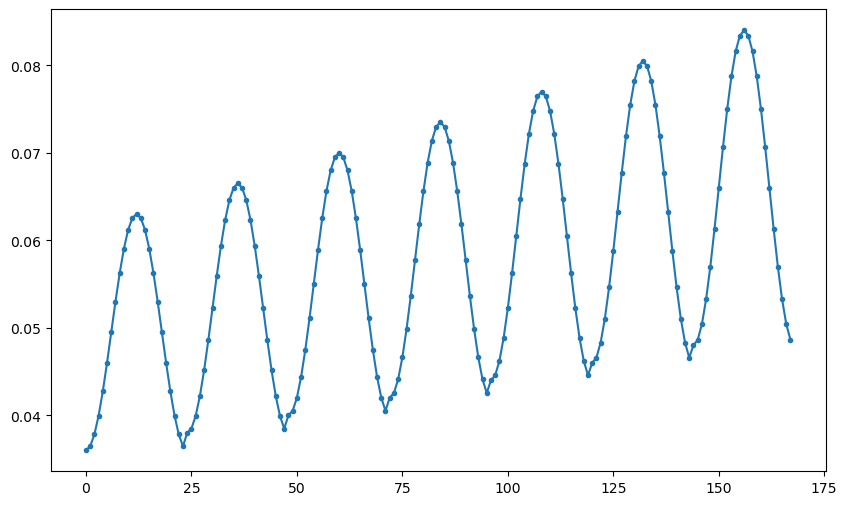

In [4]:
## scenario 2
## add trend
day_len=24
days=np.arange(0, len(new_wave), day_len)
# linear coefficient
trend=np.linspace(0.9, 1.2, 7)
data2=new_wave.copy()
# loop through each day and add trend
for day, m in zip(days, trend):
    data2[day:day+day_len]=data2[day:day+day_len]*m
# show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(data2, marker='.')

### Scenario 3: break point in trend and fixed amplitude
A breakpoint with a sudden 133% change was added at the end of Day 3 (72 hours) to simulate sudden changes in water mass or cell ppulation.

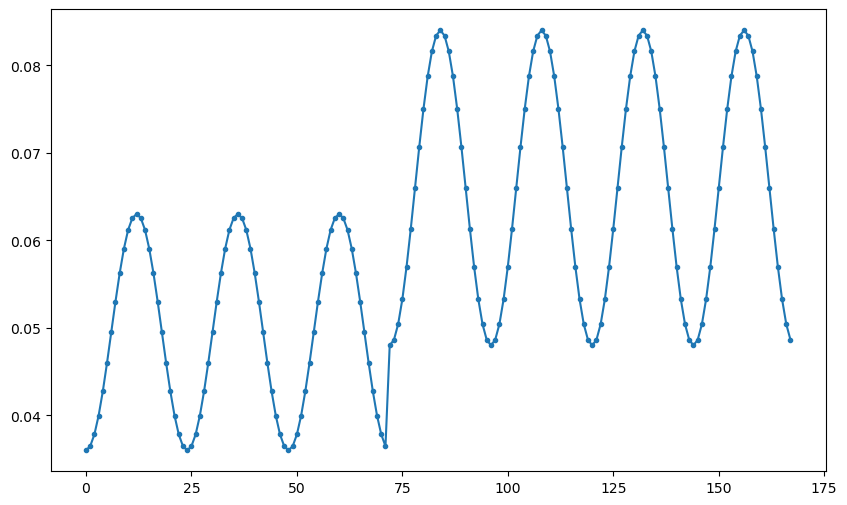

In [5]:
## scenario 3
data3=new_wave.copy()
# separate first 3 days
chunk1=new_wave[:day_len*3]*0.9
chunk2=new_wave[day_len*3:]*1.2
# concatenate
breaks=np.concatenate([chunk1,chunk2])

# # show simulation data
fig,axs=plt.subplots(figsize=(10,6))
axs.plot(breaks, marker='.')

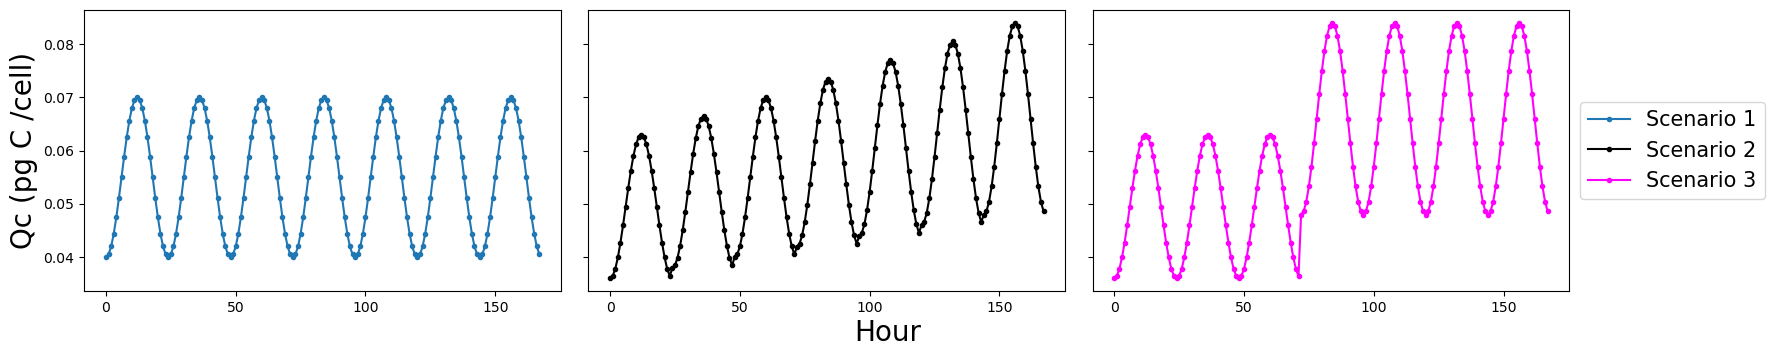

In [6]:
# scenarios 1-3 simulation data all together 
fig,axs=plt.subplots(figsize=(18,3.5), ncols=3, sharey=True)
ln1=axs[0].plot(new_wave, marker='.', label='Scenario 1')
axs[0].set_ylabel('Qc (pg C /cell)', size=20)
ln2=axs[1].plot(data2, marker='.', c='k', label='Scenario 2')
ln3=axs[2].plot(breaks, marker='.', c='magenta', label='Scenario 3')
fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':15})
lns=ln1+ln2+ln3
labs = [l.get_label() for l in lns]
axs[2].legend(lns,labs,loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Modify Diel amplitudes for each scenario
To represent cell populations changing their growth rates throughout a cruise, the next 3 scenario included a modulating amplitude. The trends were modified the same way as for scenarios 1-3, resulting in:
- Scenario 4: constant trend, changing amplitude
- Scenario 5: changing trend, changing amplitude
- Scenario 6: breakpoint in trend, changing amplitude

Here, the amplitude is linearly incrased throughout the week, representing a gradually increasing growth rate. 

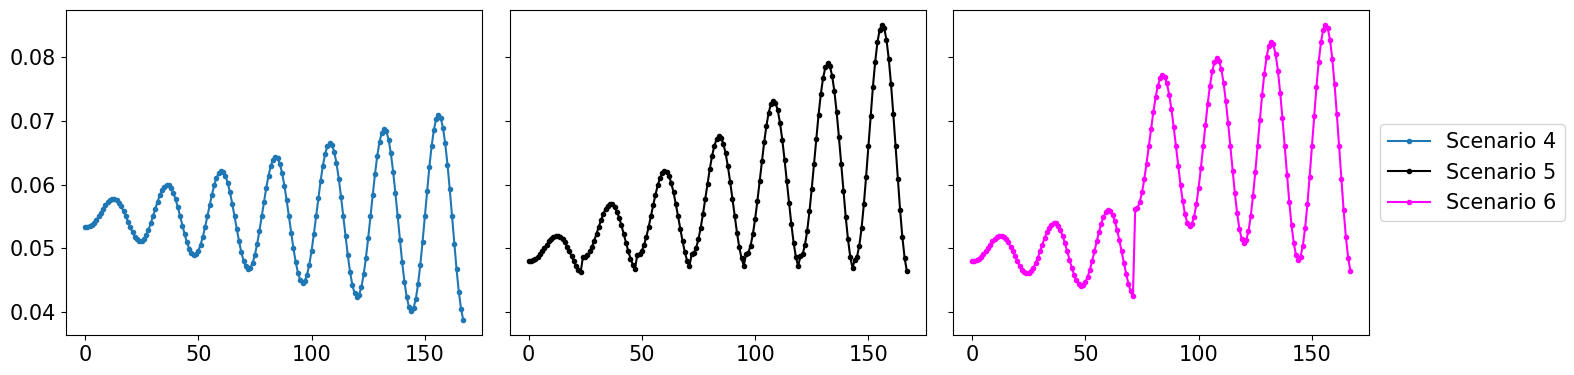

In [7]:
## scenario 4
# generate simulation data with known periodicity of 24H, 10 full days
cycles = 8 # how many sine cycles
resolution = cycles*24 # how many datapoints to generate
# calculate length
length = np.pi * 2 * cycles
# set x with custom amplitude
x=np.arange(0, length, length / resolution)
# adjust amplitude
my_wave = np.sin(x)
# original function: np.sin(x)*0.15 + 0.55
## modulate amplitude to increase each day
am_wave=my_wave*x*0.0035+0.55
# trim start/end to result in 1 week (7 days) dataset
start=np.where(my_wave == np.min(my_wave))[0][0]
end=np.where(my_wave == np.min(my_wave))[0][-1]-1
# crop wave
moving_wave=am_wave[start:end+1]/10

## scenario 5
day_len=24
moving_data2=moving_wave.copy()
# loop through eacy day
for day, m in zip(days, trend):
    moving_data2[day:day+day_len]=moving_data2[day:day+day_len]*m

plt.show()

## scenario 6
moving_data3=moving_wave.copy()
# separate first 3 days
chunk1=moving_wave[:day_len*3]*0.9
chunk2=moving_wave[day_len*3:]*1.2
# concatenate
moving_breaks=np.concatenate([chunk1,chunk2])

# show simulation data
fig,axs=plt.subplots(figsize=(16,4),ncols=3,sharey=True)
ln1 = axs[0].plot(moving_wave,marker='.', label = 'Scenario 4')
ln2 = axs[1].plot(moving_data2,marker='.',c='k', label = 'Scenario 5')
ln3 = axs[2].plot(moving_breaks, marker='.',c='magenta', label = 'Scenario 6')
# add legend
lns=ln1+ln2+ln3
labs = [l.get_label() for l in lns]
axs[2].legend(lns,labs,loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Calculate true Growth Rate (µ) for each scenario
Method to calculate growth rate (Hynes et al. 2024): ln(QC)=r×t+ln(QC,0)

- Growth rates are the same every day for Scenarios 1-3
- Growth rates change daily for Scenarios 4-6

In [8]:
# helper function to calculate growth rate from clean datasets
def calc_ideal_growths(df, col, scenario):
    ## let's assume when day and night are based on zinser dataset
    df['time_of_day']='night'
    # rename columns and create new col to specify dataset
    df.rename(columns = {col: 'Qc'}, inplace=True)
    df['scenario'] = scenario
    # save calculated daily growth rates
    actual_growth=[]
    pvals=[]
    # sunrise 1 hour after minimum, sunset 1 hour after maximum
    day_len=12
    for day in days:
        start=day+1
        # set sunrise and sunset
        df.loc[start,'time_of_day']='sunrise'
        df.loc[start+day_len,'time_of_day']='sunset'
        df[start+1:start+day_len]['time_of_day']='day'
        # calcaulate daily averaged hourly growth since sunrise
        slope, pval, se=calc_daily_avg_growth(df[start:start+day_len], 'Qc')
        actual_growth.append(slope)
        pvals.append(pval)
        # calcualte hourly growth
        df.loc[np.arange(start,start+day_len),'hourly_growth']=exp_growth(df[start:start+day_len], 'Qc', 1)
        df.loc[df['hourly_growth'].isnull(), 'hourly_growth']=0
    return df

In [9]:
# store data in df 
sim_df=pd.DataFrame([new_wave, data2, breaks,moving_wave,moving_data2,moving_breaks]).T
sim_df.columns=['data1','data2','data3','moving_data1','moving_data2','moving_data3']

# save rates 
rates_list = []
count = 1
# calculate ideal growth rates for each scenario dataset
for col in sim_df:
    rates_df = calc_ideal_growths(sim_df[[col]], col, count)
    rates_list.append(rates_df)
    count += 1

### Run simulations for each scenario

In [10]:
# ## helper function to run imputation function and fill in data
# # input: missing_df=dataframe with 'with_missing' column with data removed
# # returns: final_impute=dataframe with imputed data in 'with_missing'
# def run_imputation(missing_df,col,missing_col='with_missing', data_type='simulation',
#                    period=12, interval=2):
#     # create subsetted df excluding nan values 
#     missing_cont=missing_df.loc[missing_df[missing_col].notna()]
    
#     # run seasonal decomposition on raw data and drop nan values for now
#     train=missing_cont[missing_col]
#     ############ debugging ########################
#     display(train)
#     print(f'Period: {period}')
#     print(f'Interval: {interval}')
#     ################################################

#     try: 
#         decompose=seasonal_decompose(train, model='multiplicative', period=period, extrapolate_trend='freq')
#     except: 
#         print('Not enough data for imputation')
#         return
#     #get trend and seasonal components
#     missing_cont.loc[train.index, 'trend']=decompose.trend
#     missing_cont.loc[train.index, 'seasonal']=decompose.seasonal

#     # check what kind of data to set up for interpolation
#     if data_type=='simulation':
#         # set index as time for interpolation for experimental/simulation data
#         missing_cont.set_index('hour',inplace=True)
#         # grab first and last hours of complete dataframe
#         hour_range=missing_df.iloc[[0,-1]]['hour'].values
#         # create resamppled list 
#         resampled=np.arange(hour_range[0],hour_range[1]+1, interval)
#         # resample interpolated list
#         missing_resamp = missing_cont.reindex(missing_cont.index.union(
#             resampled)).interpolate('values',limit_direction='both').loc[resampled]
#         # add missing diam_med data back to interpolated data
#         missing_resamp[missing_col]=missing_cont[missing_col]
#             # add flag to check if filled
#         missing_resamp['filled']=0
#         # iteratively impute
#         pre_impute =iteratively_impute(missing_resamp, missing_col)
#         # fill additional gaps with linear interpolation
#         final_impute = pre_impute.reindex(pre_impute.index.union(
#             resampled)).interpolate(limit_direction='both',axis=0).loc[resampled].reset_index()
#         # replace altered with its original values
#         if col.startswith('data'):
#             final_impute[col]=missing_df[col].values
#         else:
#             final_impute['Qc_hour']=missing_df['Qc_hour']
#             final_impute['NPP']=missing_df['NPP']
#             final_impute['par']=missing_df['par']
#     else:
#         # set index as time for interpolation for field data
#         missing_resamp=missing_cont.reset_index(drop=True).copy()
#         missing_cont.set_index('time',inplace=True)
#         # resample and get only fill missing_col values
#         missing_resamp=missing_cont.resample('1H').agg(pd.Series.sum, 
#                                                   min_count=1).reset_index()
        
#         # add flag to check if filled
#         missing_resamp['filled']=0
#         # iteratively impute
#         pre_impute=iteratively_impute(missing_resamp, missing_col).set_index('time')
#         # fill additional gaps with linear interpolation
#         final_impute = pre_impute.resample('1H').mean().interpolate(method='linear').reset_index()
#         # add cruise and population data back, and original data with missing values
#         final_impute['cruise']=pd.unique(missing_cont['cruise'])[0]
#         final_impute['pop']=pd.unique(missing_cont['pop'])[0]
#         final_impute[col]=missing_resamp[col]

#     return(final_impute)


# ## running entire model w/o bootstrapping or zinser data
# def run_full_model(df, col, remove=0, noise=0, blocks=False, model='STL', show_plots=True):
#     # first generate noise if prompted
#     if noise > 0:
#         # calculate std to sample from noise
#         x=df[col]
#         # set mean to 0 for gaussian noise
#         mu=0
#         # multiply noise by Qc standard deviation
#         std = noise * np.std(x) 
#         # add noise to data
#         df['data_with_noise']=gaussian_noise(x,mu,std)
#     # don't generate noise    
#     else:
#         df['data_with_noise']=df[col]
    
#     # generate missing data if prompted
#     if remove > 0:
#         # generate blocks of missing datam
#         if blocks:
#             # remove block length and amount of data to remove
#             missing=generate_random_chunks(df,'data_with_noise',remove, missing_col='data_with_missing')
#         else:
#             # generate misisng data at random
#             missing=generate_missing_data(df, 'data_with_noise', remove,missing_col='data_with_missing')
#         # save missing data
#         missing_data=missing['data_with_missing']
#         # calculate imputed values
#         impute_df=run_imputation(missing, 'data_with_noise', missing_col='data_with_missing',period=24, interval=1)
        
#         ############ debugging ########################
#         # display(missing)
#         ################################################
        
#         # rename col
#         impute_df.rename(columns={'with_missing':'data_with_missing'},inplace=True)
#         # reset time of day columns
#         impute_df['time_of_day']=df['time_of_day']
#         # check if imputation ran
#         if impute_df is None:
#             print('Imputation Failed')
#             return
#     else: # run STL model on complete dataset (no missing values)
#         # add necessary columns
#         impute_df=df.copy()
#         # replace with noise column (doesn't matter if noise was added or not)
#         impute_df['with_missing']=impute_df['data_with_noise']
#         # check if there are missing values, and replace with noise
#         impute_df['data_with_missing']=np.where(impute_df['with_missing']>0, impute_df['with_missing'], 
#          np.mean(impute_df['with_missing']))
#         # save missing data
#         missing_data=impute_df['data_with_missing']

#     ## run STL model
#     if model.lower().startswith('s'):
#         # get tsd components
#         tsd_df=run_STL(impute_df, col='data_with_missing',period=24)
#         # calculate growth
#         growth_df=calc_diel_growth(tsd_df, 'diel', model)
#         growth_df['remove']=remove
#         growth_df['noise']=noise
#     ## run naive model
#     elif model.lower().startswith('n'):
#         # get tsd components
#         tsd_df=run_naive(impute_df, col='data_with_missing',period=24)
#         # save missing components 
#         tsd_df['unfilled']=missing_data
#         growth_df=calc_diel_growth(tsd_df, 'diel', model)
#         growth_df['remove']=remove
#         growth_df['noise']=noise
#     ## run STL model
#     elif model.lower().startswith('roll'):
#         # get components from rolling model
#         pro_seasonal, pro_trend, pro_resid = rolling_tsd(impute_df.set_index('hour'), 'data_with_missing', period=24,
#                                                         window=3, type='log additive', extrapolate=True)
#         pro_all=summarize_rolling(pro_seasonal, pro_trend, pro_resid)
#         pro_all.rename(columns={'seasonal':'diel'}, inplace=True)
#         # get other necessary columns`a
#         tsd_df=pd.merge(pro_all, impute_df[['hour','time_of_day','data_with_missing']], on='hour')
#         # calculate growth and productivity
#         growth_df=calc_diel_growth(tsd_df, 'diel', model)
#         growth_df['remove']=remove
#         growth_df['noise']=noise
#     ## run baseline model (just dusk+dawn, no decomposition)
#     elif model.lower().startswith('base'):
#         tsd_df=impute_df.copy()
#         # replace with missing data (don't use imputed values) if remove >0; else leave as is
#         if remove > 0:
#             tsd_df['data_with_missing']=missing['data_with_missing']
#         growth_df=calc_diel_growth(tsd_df, 'data_with_missing', model)
#         growth_df['remove']=remove
#         growth_df['noise']=noise
#         # remove unnecessary columns
#         #tsd_df.drop(columns = ['Qc', 'hourly_growth', 'pop'], inplace = True)
        
#     else: 
#         return('Choose a valid model: baseline, naive, rolling, or STL')
#     return(tsd_df, growth_df)

In [30]:
#### testing #####
## Missing data trial ##
df = rates_list[0]
df['hour'] = df.index
model = 'base'
data_level = 0.3

tsd_result, growth_result = model_trial(df, model, "remove", data_level)

rmse = (tsd_result['rmse'].unique()[0])
print(rmse)

0.05023007232000176


In [31]:
import os

# check if files exist
noise_tsd_path = '../data/noise_simulation_results_all.pickle'
remove_tsd_path = '../data/remove_simulation_results_all.pickle'

if os.path.exists(noise_tsd_path) & os.path.exists(remove_tsd_path):
    noise_tsd_all = pd.read_pickle(noise_tsd_path)
    remove_tsd_all = pd.read_pickle(remove_tsd_path)
else:
    scenarios=['data1','data2','data3','moving_data1','moving_data2','moving_data3']
    models=['base']#, 'naive','rolling','stl']
    # start data removed experiments
    data_levels=np.linspace(0,1,11)
    # data_levels=np.arange(0, 0.9, 0.1)
    # save dataframes for TSD and growth rates for data removal + noise addition experiments
    remove_tsd_results=[]
    remove_growth_results=[]
    noise_tsd_results=[]
    noise_growth_results=[]

    # Run 100 times to get random blocks of missing data and random noise
    # loop through each scenario 1-6
    for df in rates_list:
        # create column for time (hour)
        df['hour'] = df.index
        for model in models:
                # run model with data removed
                for data in data_levels:
                    # run 100x to get distribution of data
                    for i in range(0,100):
                        scenario = df['scenario'].unique()[0]
                        print(f'Data level: {data}')
                        ## Missing data trial ##
                        remove_tsd, remove_growth = model_trial(df, model, 'remove', data)
                        # if model runs without error, save to lists
                        if remove_tsd is not None:
                            remove_tsd['bootstrap_run'] = i
                            remove_growth['bootstrap_run'] = i
                            # save results
                            remove_tsd_results.append(remove_tsd)
                            remove_growth_results.append(remove_growth)
                            # Display progress 
                            rmse = remove_tsd['rmse'].unique()[0]
                            print(f'Completed Scenario: {scenario}, Model: {model}, Data Removed: {data}, RMSE: {rmse}')
                        # otherwise skip
                        else:
                                print(f'Scenario failed to run: {scenario}, Model: {model}, Data Removed: {data}')
                        ## Noise addition trial ## 
                        noise_tsd, noise_growth = model_trial(df, model, 'noise', data)
                        # if model runs without error, save to lists
                        if noise_tsd is not None:
                            noise_tsd['bootstrap_run'] = i
                            noise_growth['bootstrap_run'] = i
                            # save results
                            noise_tsd_results.append(noise_tsd)
                            noise_growth_results.append(noise_growth)
                            # Display progress 
                            rmse = noise_tsd['rmse'].unique()[0]
                            print(f'Completed Scenario: {scenario}, Model: {model}, Proportion Noise Added: {data}, RMSE: {rmse}')
                        # otherwise skip
                        else:
                                print(f'Scenario failed to run: {scenario}, Model: {model}, Proportion Noise Added: {data}')

    ### save the data for noise addition trials
    noise_tsd_all = pd.concat(noise_tsd_results)
    noise_tsd_all.to_pickle('../data/noise_simulation_results_all.pickle')
    ## save data for data removeal trials
    remove_tsd_all = pd.concat(remove_tsd_results)
    remove_tsd_all.to_pickle('../data/remove_simulation_results_all.pickle')

### Figure 1 ###

#### Panel A

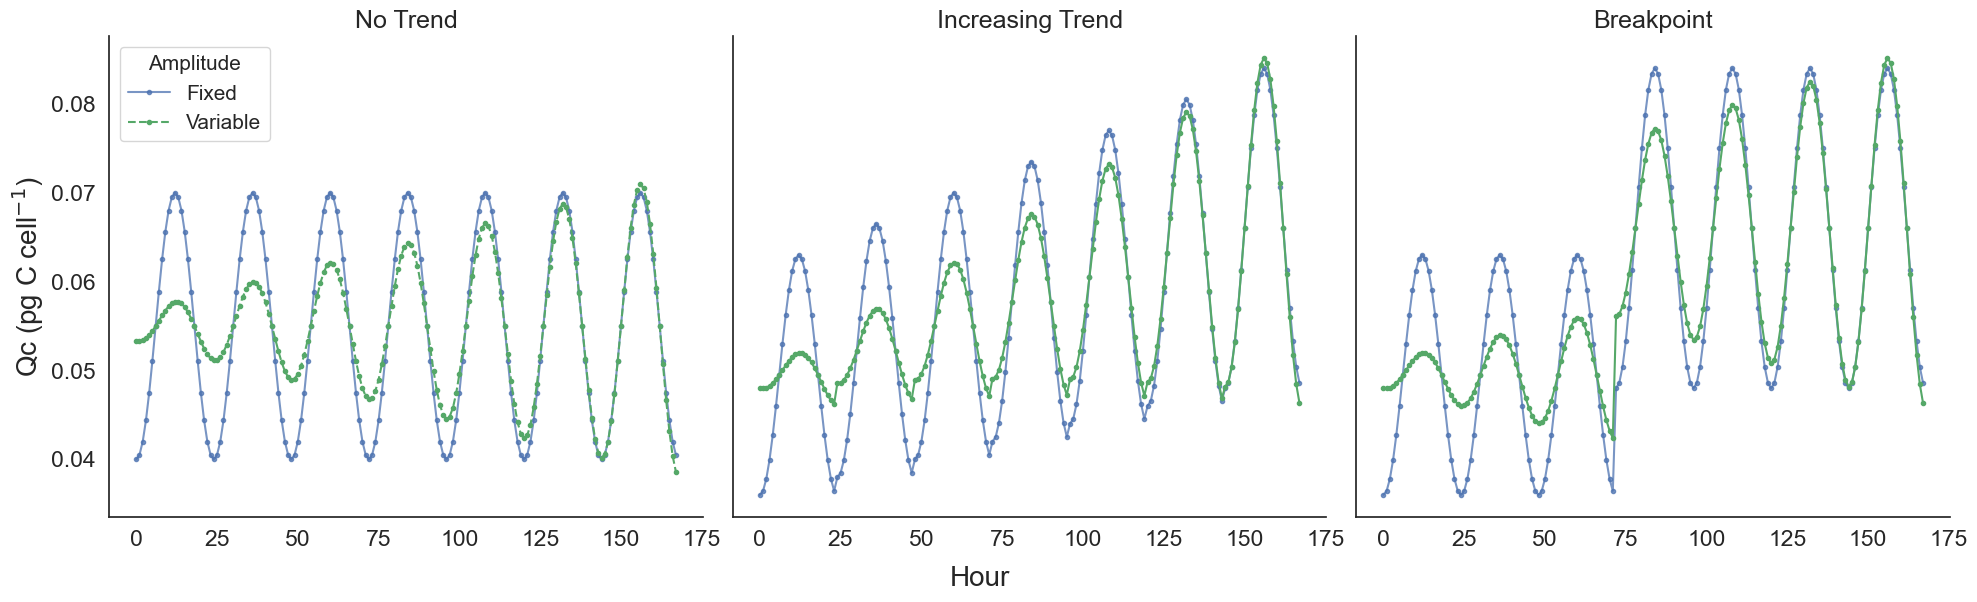

In [33]:
### Show simulated data (fig 1 panel A)
sns.set_style('white')
# show simulation data
fig,axs=plt.subplots(figsize=(20,6), ncols=3, sharey=True)
## plot scenario 1
ln1=axs[0].plot(new_wave, marker='.', label='Fixed', alpha=0.75)
d1=axs[0].plot(sim_df['moving_data1'], marker='.', c='g',linestyle='--',label='Variable')
lns=ln1+d1
labs = [l.get_label() for l in lns]
axs[0].legend(lns,labs, title = 'Amplitude', loc='upper left', fontsize = 15, title_fontsize=15)
axs[0].set_title('No Trend')
axs[0].set_ylabel('Qc (pg C cell$^{-1}$)', size=20)

## plot scenario 2
ln2=axs[1].plot(data2, marker='.', label='3', alpha=0.75)
d3=axs[1].plot(sim_df['moving_data2'], marker='.', c='g', label='4')
lns=ln2+d3
labs = [l.get_label() for l in lns]
# axs[1].legend(lns,labs, title = 'Scenarios', loc='upper left', fontsize = 12, title_fontsize=12)
axs[1].set_title('Increasing Trend')


## plot scenario 3
ln3=axs[2].plot(breaks, marker='.', label='5', alpha=0.75)
d3=axs[2].plot(sim_df['moving_data3'], marker='.', c='g', label='6')
lns=ln3+d3
labs = [l.get_label() for l in lns]
# axs[2].legend(lns,labs, title = 'Scenarios', loc='upper left', fontsize = 12, title_fontsize=12)
axs[2].set_title('Breakpoint')

# add text and set font size

fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':20})
# remove top and right spines for all axes
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Plot aggregated results of simulations, scenarios 1 - 6


In [34]:
# get rmse for each day in each resulting df, add cols for plotting
noise_error = noise_tsd_all.groupby(['model', 'scenario', 'noise', 'bootstrap_run']).mean().reset_index()
noise_error.rename(columns = {'noise': 'data level'}, inplace=True)
noise_error['trial'] = 'Added Noise'
remove_error = remove_tsd_all.groupby(['model', 'scenario', 'remove', 'bootstrap_run']).mean().reset_index()
remove_error.rename(columns = {'remove': 'data level'}, inplace=True)
remove_error['trial'] = 'Missing Data'
# create aggregated file
all_trials = pd.concat([noise_error, remove_error])

# Distinguish between Scnarios 1-3 and 4-6
all_trials.loc[all_trials['scenario'] < 4, 'diel'] = 'Fixed Amplitude'
all_trials.loc[all_trials['scenario'] >= 4, 'diel'] = 'Variable Amplitude'

# group scenario types by trends
all_trials.loc[(all_trials['scenario'] == 1) | (all_trials['scenario'] == 4), 'trend'] = 'No Trend'
all_trials.loc[(all_trials['scenario'] == 2) | (all_trials['scenario'] == 5), 'trend'] = 'Increasing Trend'
all_trials.loc[(all_trials['scenario'] == 3) | (all_trials['scenario'] == 6), 'trend'] = 'Breakpoint'

### Fig. 1B, 1C

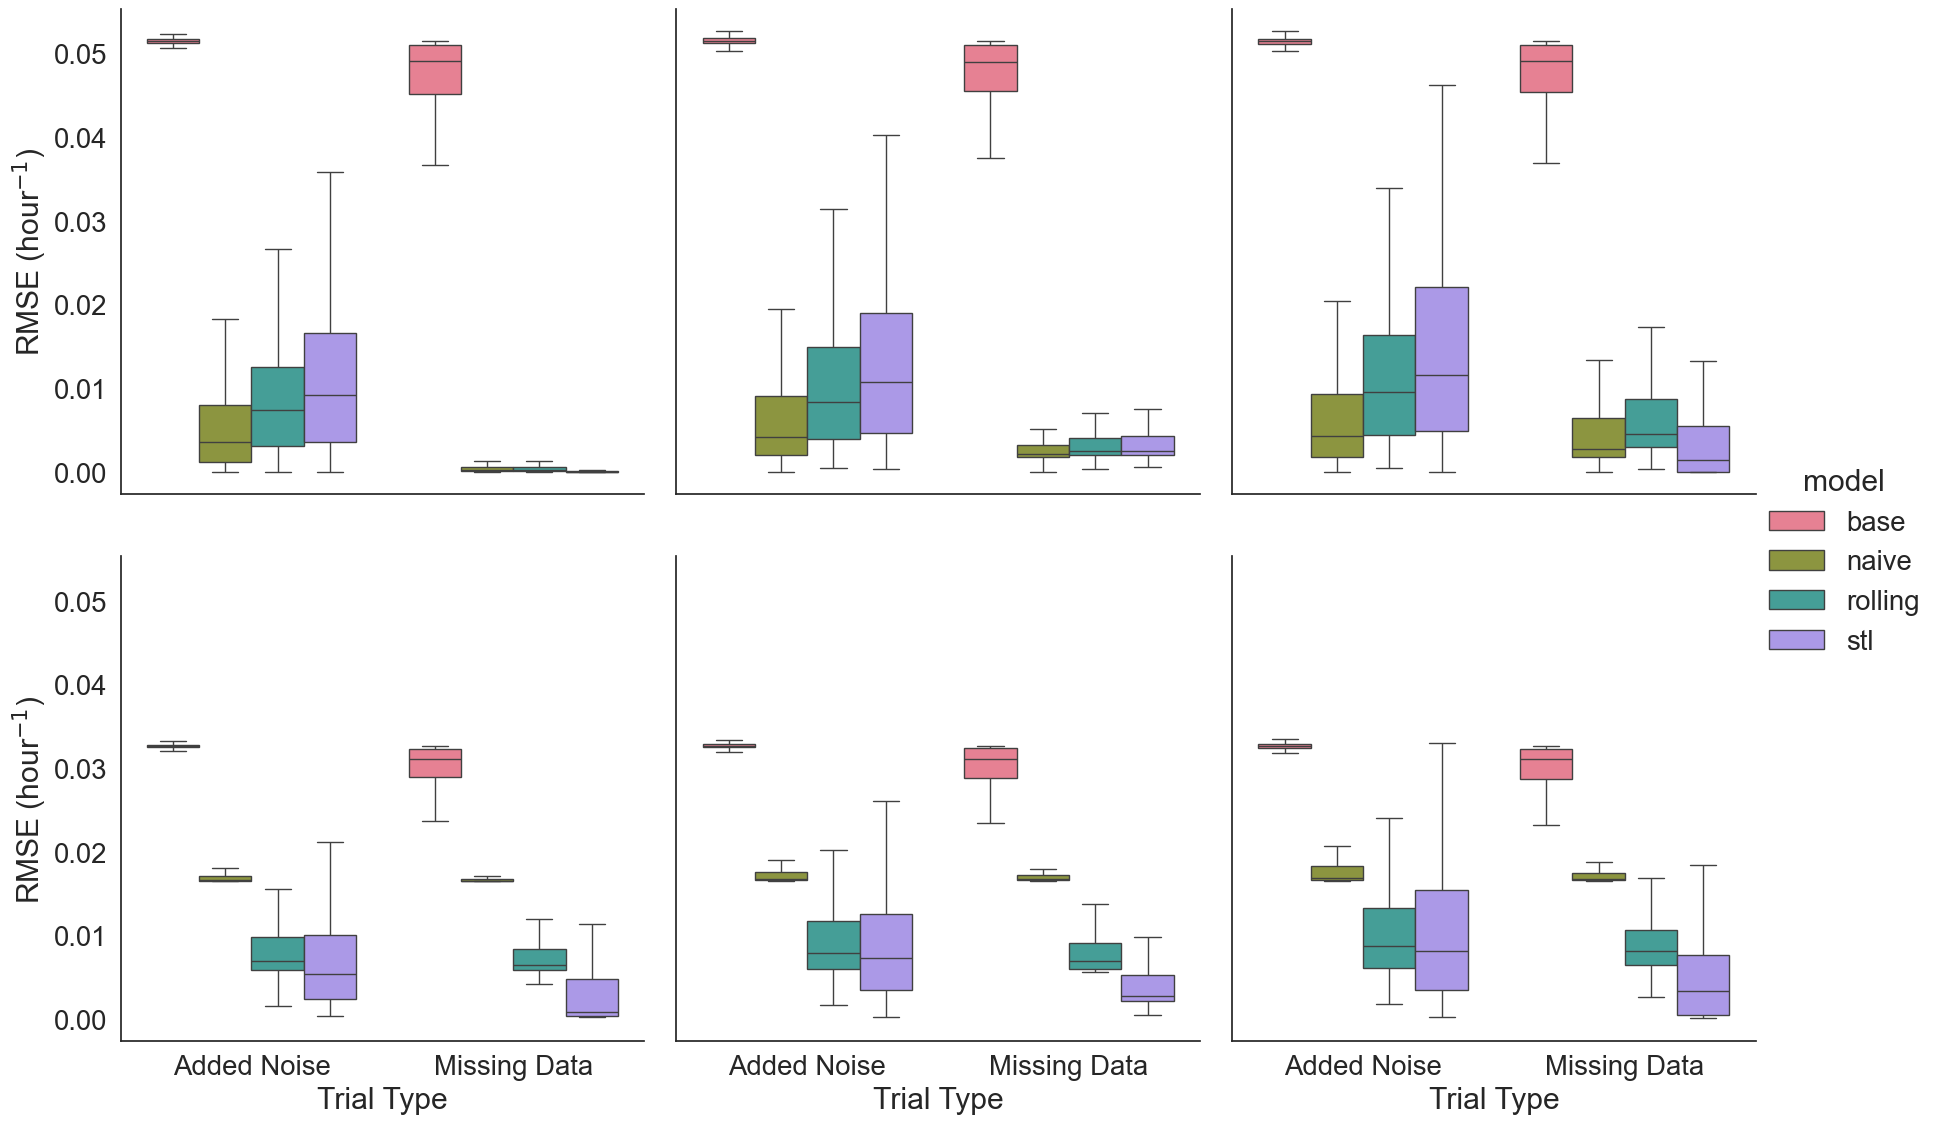

In [35]:
sns.set_theme(font_scale=1.8)
sns.set_style(style='white')
hue_order = ['base', 'naive', 'rolling', 'stl']
g = sns.catplot(data=all_trials, x='trial', y='rmse', hue='model', col='trend',
                row='diel', kind='box',palette='husl',
               errorbar='se',height=6, hue_order=hue_order, showfliers=False)
# plt.legend()
g.set_axis_labels("Trial Type",'RMSE (hour$^{-1}$)')
g.set_titles(template="")
plt.show()

### Supplementary figure with all data levels

#### Fig. S4
- Constant Diel 

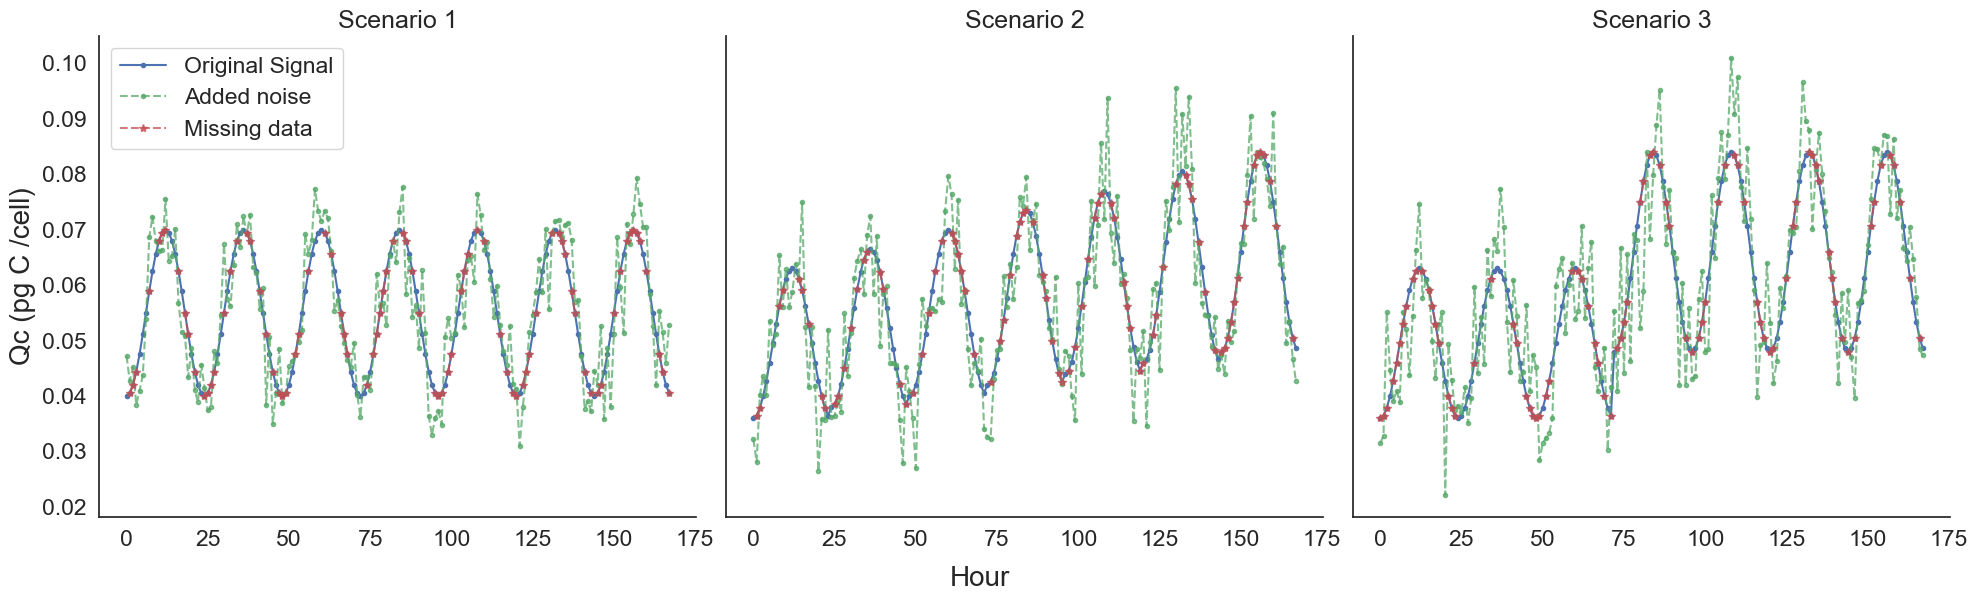

In [ ]:
sns.set_style('white')
# show simulation data
fig,axs=plt.subplots(figsize=(20,6), ncols=3, sharey=True)
#### plot scenario 1 ####
## loop through each plot and plot noise/missing data for Supp Fig
ax_count = 0
# constant diel cols
cols = ['data1', 'data2', 'data3']
data_level = 0.5

for col in cols: 
    ### manipulate clean original signal
    constant_diel = sim_df[col]

    # calculate std to sample from noise
    x=constant_diel
    # set mean to 0 for gaussian noise
    mu=0
    # multiply noise by Qc standard deviation
    std = data_level * np.std(x) 
    # add noise to data
    noise_ex = gaussian_noise(x,mu,std)
    ## remove data
    missing_df = sim_df.copy()
    missing_df = generate_missing_data(missing_df, col, data_level , missing_col='data_with_missing')

    # plot original data
    ln1=axs[ax_count].plot(sim_df[col], marker='.', label='Original Signal')
    # plot data with noise
    d1=axs[ax_count].plot(noise_ex, marker='.', c='g',linestyle='--',label='Added noise', alpha=0.75)
    # plot data with removal
    d2 = axs[ax_count].plot(missing_df['data_with_missing'], marker='*', c='r', linestyle='--',label='Missing data', alpha=0.75)
    axs[ax_count].set_title(f'Scenario {ax_count + 1}')
    # increment axis 
    ax_count += 1

lns = ln1+ d1 + d2
labs = [l.get_label() for l in lns]
axs[0].legend(lns,labs,loc='upper left')
axs[0].set_ylabel('Qc (pg C /cell)', size=20)

# add text and set font size
fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':20})
# remove top and right spines for all axes
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

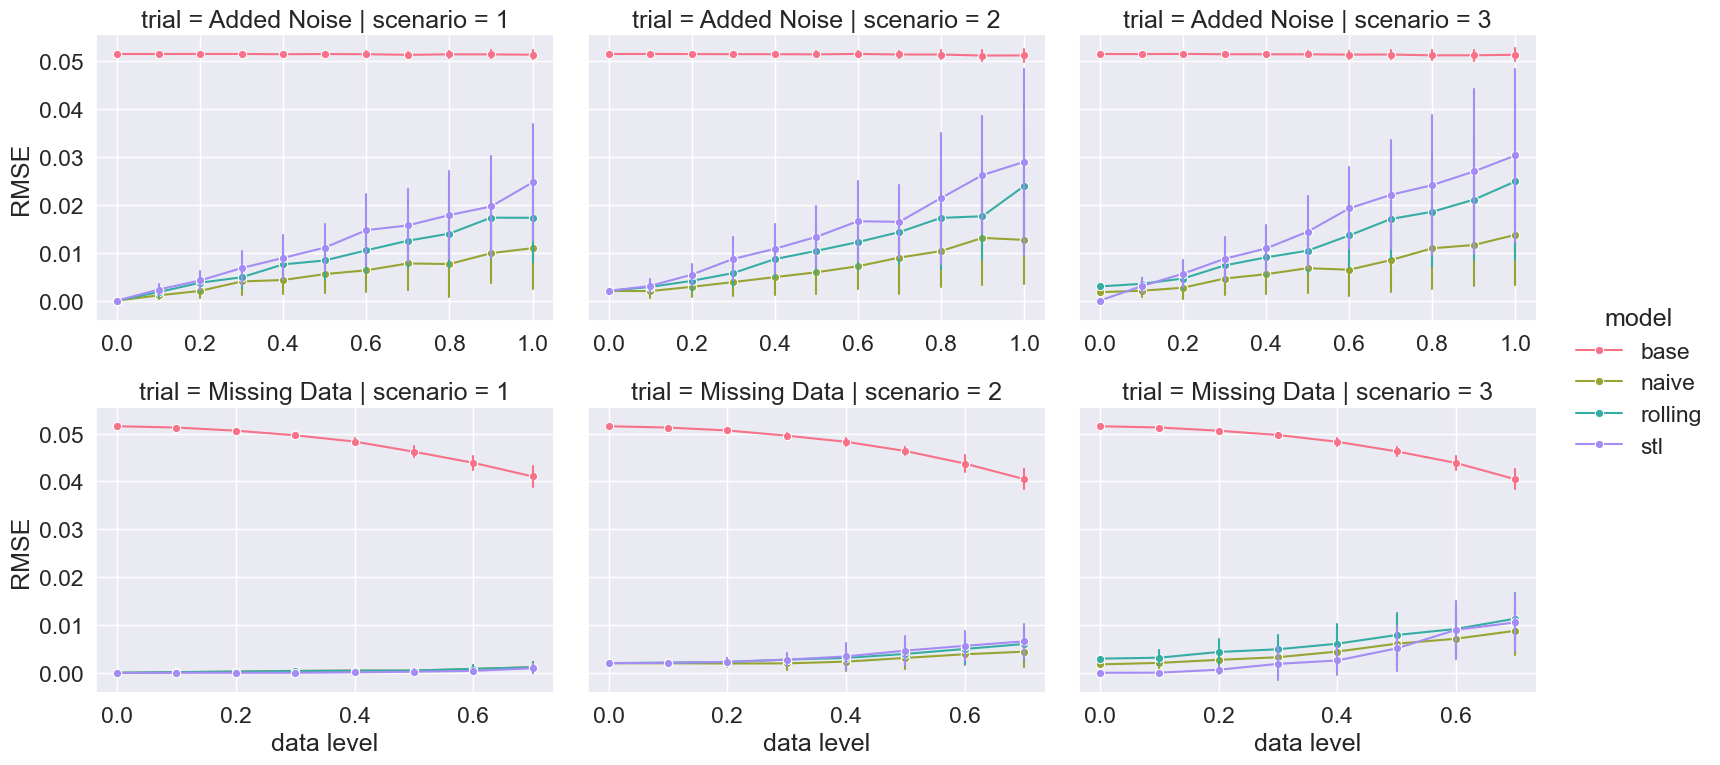

In [38]:
# plot increasing data removed
sns.set(font_scale=1.5)
constant_diel_df = all_trials.loc[all_trials['diel'] == 'Fixed Amplitude']
g = sns.FacetGrid(constant_diel_df, col="scenario", row='trial', hue='model',sharey=True, sharex=False,
                 height=4, aspect=1.2, palette = 'husl')
g.map(sns.lineplot, "data level", "rmse", marker='o',err_style='bars',ci='sd', legend = True)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left', borderaxespad=0.)
# g.set_axis_labels("Noise Added")
axes = g.axes.flatten()
axes[0].set_ylabel('RMSE')
axes[3].set_ylabel('RMSE')
plt.tight_layout()
plt.show()

### Fig S5

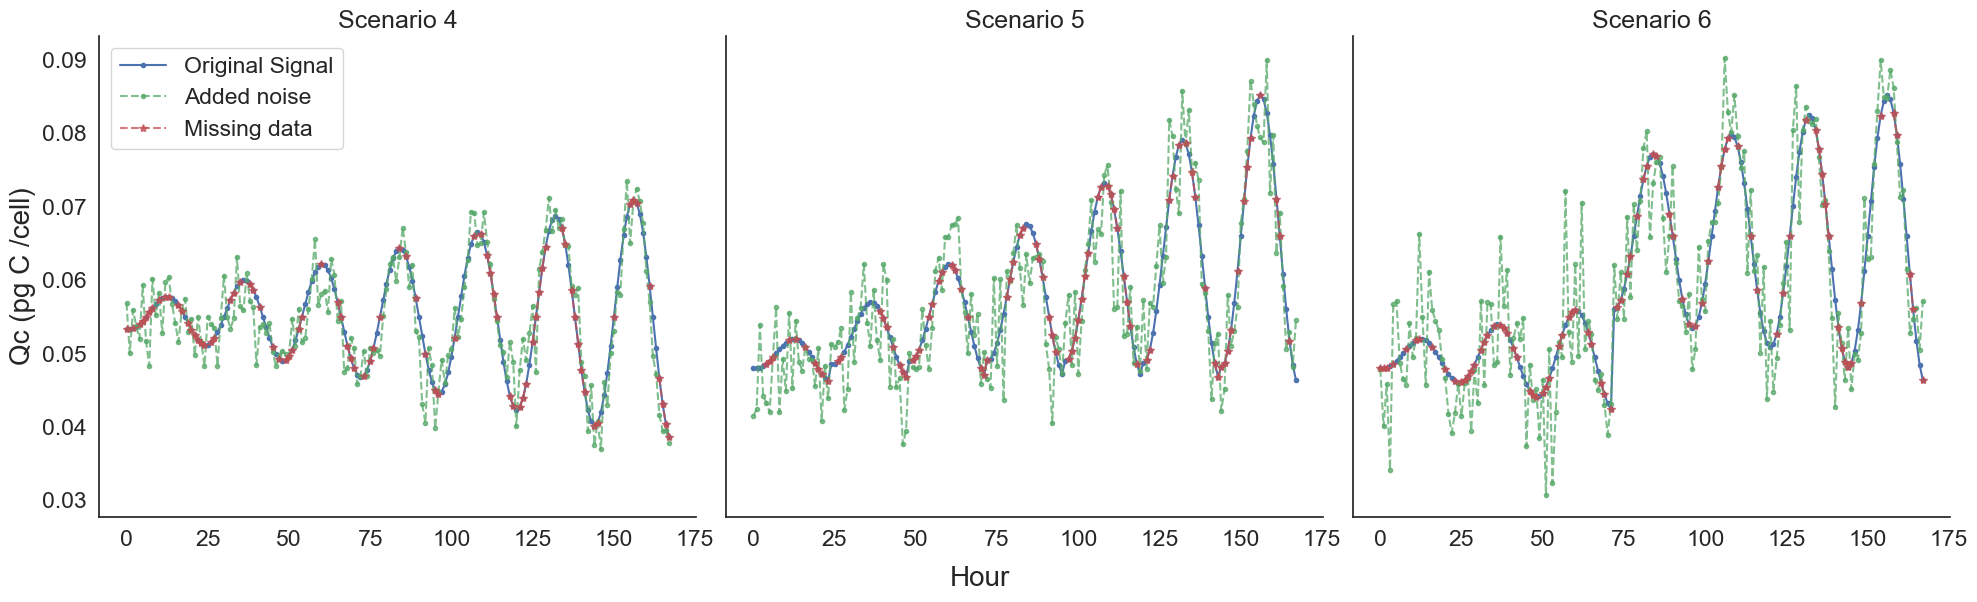

In [80]:
sns.set_style('white')
# show simulation data
fig,axs=plt.subplots(figsize=(20,6), ncols=3, sharey=True)
#### plot scenario 1 ####
## loop through each plot and plot noise/missing data for Supp Fig
ax_count = 0
# constant diel cols
cols = ['moving_data1', 'moving_data2', 'moving_data3']
data_level = 0.5

for col in cols: 
    ### manipulate clean original signal
    constant_diel = sim_df[col]

    # calculate std to sample from noise
    x=constant_diel
    # set mean to 0 for gaussian noise
    mu=0
    # multiply noise by Qc standard deviation
    std = data_level * np.std(x) 
    # add noise to data
    noise_ex = gaussian_noise(x,mu,std)
    ## remove data
    missing_df = sim_df.copy()
    missing_df = generate_missing_data(missing_df, col, data_level , missing_col='data_with_missing')

    # plot original data
    ln1=axs[ax_count].plot(sim_df[col], marker='.', label='Original Signal')
    # plot data with noise
    d1=axs[ax_count].plot(noise_ex, marker='.', c='g',linestyle='--',label='Added noise', alpha=0.75)
    # plot data with removal
    d2 = axs[ax_count].plot(missing_df['data_with_missing'], marker='*', c='r', linestyle='--',label='Missing data', alpha=0.75)
    axs[ax_count].set_title(f'Scenario {ax_count + 4}')
    # increment axis 
    ax_count += 1

lns = ln1+ d1 + d2
labs = [l.get_label() for l in lns]
axs[0].legend(lns,labs,loc='upper left')
axs[0].set_ylabel('Qc (pg C /cell)', size=20)

# add text and set font size
fig.text(0.5, -0.01, 'Hour', ha='center', size=20)
plt.rcParams.update({'font.size':20})
# remove top and right spines for all axes
for ax in axs: 
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

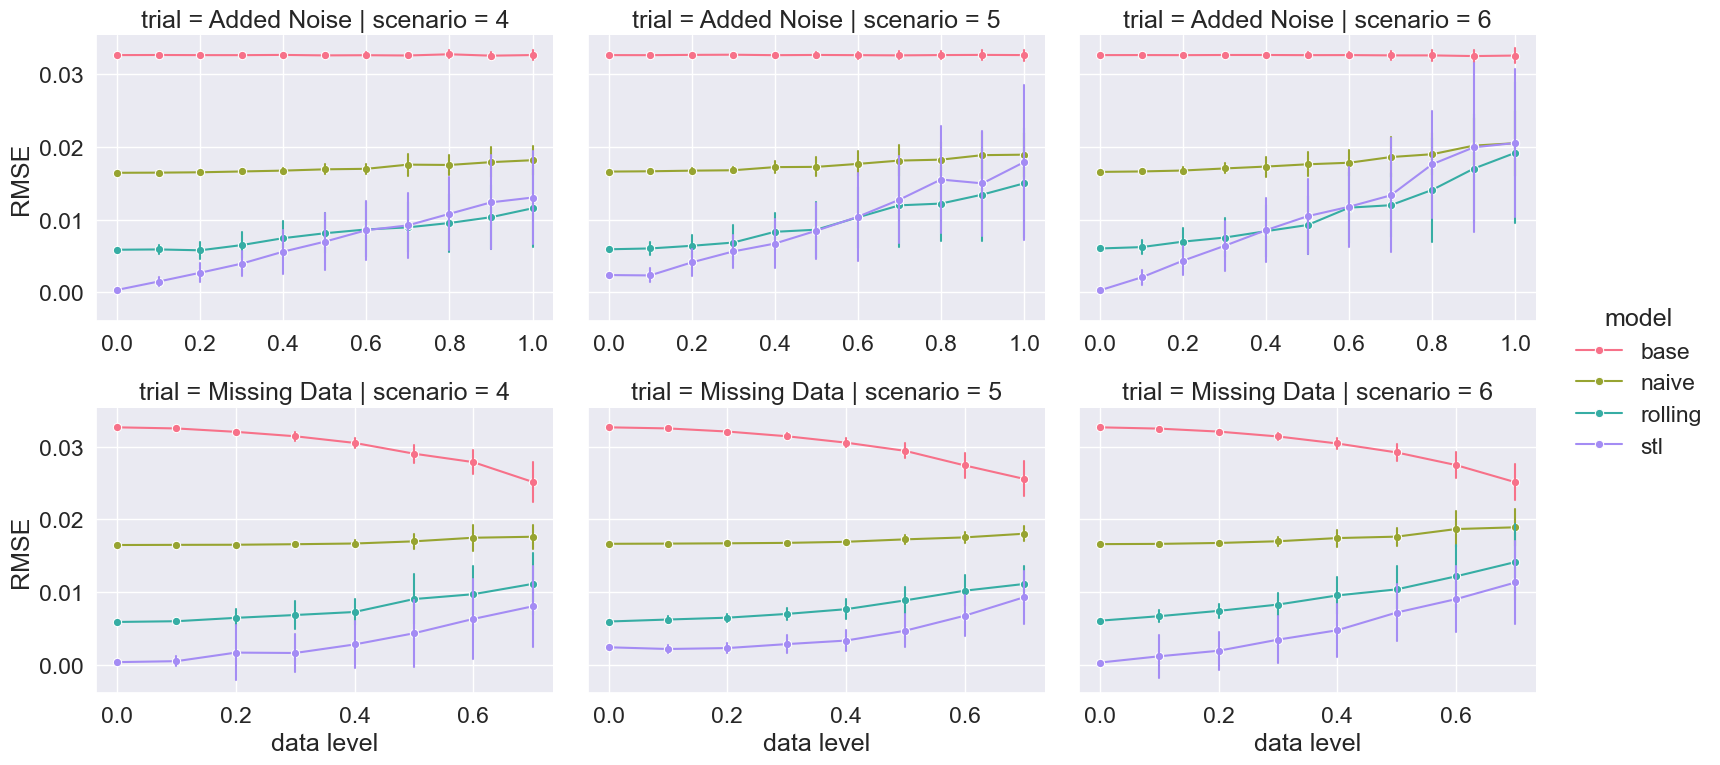

In [39]:
# plot increasing data removed
sns.set(font_scale=1.5)
var_diel_df = all_trials.loc[all_trials['diel'] == 'Variable Amplitude']
g = sns.FacetGrid(var_diel_df, col="scenario", row='trial', hue='model',sharey=True, sharex=False,
                 height=4, aspect=1.2, palette = 'husl')
g.map(sns.lineplot, "data level", "rmse", marker='o',err_style='bars',ci='sd', legend = True)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='center left', borderaxespad=0.)
# g.set_axis_labels("Noise Added")
axes = g.axes.flatten()
axes[0].set_ylabel('RMSE')
axes[3].set_ylabel('RMSE')
plt.tight_layout()
plt.show()